In [1]:
!pip install transformers datasets


In [2]:
!pip install evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 6.6 MB/s eta 0:00:00


In [13]:
from transformers import BertForSequenceClassification, BertTokenizer, Trainer, TrainingArguments
from datasets import load_dataset
import evaluate  # Importar a biblioteca evaluate

# Carregar o dataset ASSIN completo
ds = load_dataset("nilc-nlp/assin", "full")

# Carregar o tokenizador do modelo Legal-BERTimbau
tokenizer = BertTokenizer.from_pretrained('rufimelo/Legal-BERTimbau-sts-base-ma-v2')

# Definir um comprimento máximo
MAX_LENGTH = 128

# Função para tokenizar as entradas
def tokenize_function(examples):
    return tokenizer(examples['premise'], examples['hypothesis'], padding="max_length", truncation=True, max_length=MAX_LENGTH)

# Aplicar a tokenização ao dataset
tokenized_datasets = ds.map(tokenize_function, batched=True)

# Adicionar os rótulos ao dataset tokenizado
tokenized_datasets = tokenized_datasets.rename_column("entailment_judgment", "labels")

# Preparar o modelo para classificação com múltiplos rótulos
model = BertForSequenceClassification.from_pretrained(
    'rufimelo/Legal-BERTimbau-sts-base-ma-v2',
    num_labels=3  # Definir o número correto de rótulos para classificação
)

# Carregar a métrica de acurácia da biblioteca evaluate
accuracy_metric = evaluate.load("accuracy")

# Função para calcular as métricas
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    return {"accuracy": accuracy['accuracy']}

# Configurar os argumentos de treinamento
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
)

# Definir o Trainer, utilizando o dataset tokenizado e a função de métricas
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics  # Adicionar a função de métricas
)

# Treinar o modelo
trainer.train()

# Avaliar o modelo no conjunto de validação
results = trainer.evaluate()

# Exibir a acurácia
print(f"Acurácia: {results['eval_accuracy']}")


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at rufimelo/Legal-BERTimbau-sts-base-ma-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.371566,0.863000
2,0.394200,0.394984,0.888000
3,0.394200,0.509373,0.888000


Acurácia: 0.888


In [14]:
from sklearn.metrics import classification_report

predictions = trainer.predict(tokenized_datasets['validation'])
y_pred = predictions.predictions.argmax(axis=-1)
y_true = tokenized_datasets['validation']['labels']

print(classification_report(y_true, y_pred, target_names=['NONE', 'ENTAILMENT', 'CONTRADICTION']))


               precision    recall  f1-score   support

         NONE       0.94      0.95      0.95       722
   ENTAILMENT       0.71      0.80      0.76       208
CONTRADICTION       0.88      0.50      0.64        70

     accuracy                           0.89      1000
    macro avg       0.84      0.75      0.78      1000
 weighted avg       0.89      0.89      0.89      1000



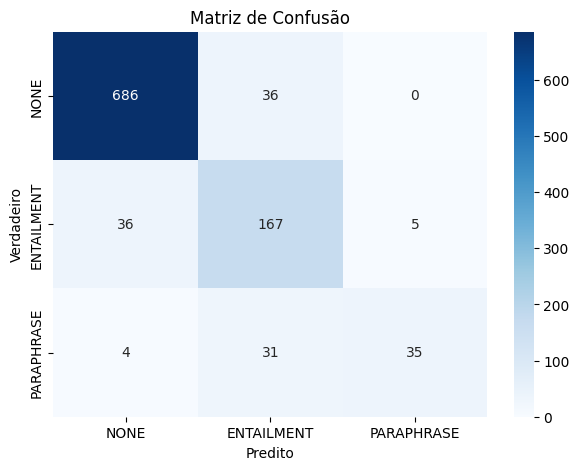

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Gerar a matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# Plotar a matriz de confusão
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NONE', 'ENTAILMENT', 'PARAPHRASE'], yticklabels=['NONE', 'ENTAILMENT', 'PARAPHRASE'])
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()


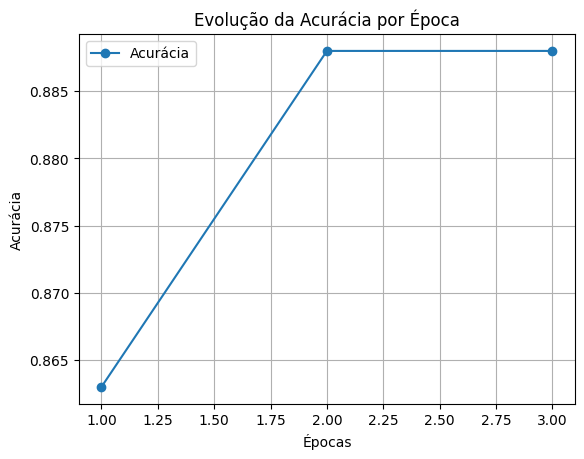

In [16]:
import matplotlib.pyplot as plt

# Dados simulados de acurácia para cada época
epochs = [1, 2, 3]
accuracies = [0.863, 0.888, 0.888]  # Valores de exemplo da acurácia

# Plotando o gráfico de acurácia por época
plt.plot(epochs, accuracies, marker='o', label='Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia por Época')
plt.grid(True)
plt.legend()
plt.show()
